# Modelo Logístico — Datos de Carlson

El modelo logístico en diferencias (mapa logístico) está dado por:

$$f(X) = X + \rho X (L - X)$$

donde:
- $X$ es la población en el tiempo $t$
- $\rho$ es la tasa de crecimiento intrínseca
- $L$ es la capacidad de carga (población máxima)

Ajustaremos $\rho$ y $L$ usando los datos experimentales de Carlson.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

# Datos de Carlson
horas = np.array([0, 1, 2, 3, 5, 7, 9, 12, 18], dtype=float)
poblacion = np.array([9.6, 18.3, 29.0, 47.2, 174.6, 441.0, 594.8, 651.1, 661.8], dtype=float)

print('Datos de Carlson:')
print(f'{"Hora":>6}  {"Población":>10}')
print('-' * 20)
for h, p in zip(horas, poblacion):
    print(f'{h:>6.0f}  {p:>10.1f}')

Datos de Carlson:
  Hora   Población
--------------------
     0         9.6
     1        18.3
     2        29.0
     3        47.2
     5       174.6
     7       441.0
     9       594.8
    12       651.1
    18       661.8


## Solución analítica del modelo logístico continuo

El modelo discreto $X_{t+1} = X_t + \rho X_t (L - X_t)$ tiene como aproximación continua la ecuación logística clásica, cuya solución es:

$$X(t) = \frac{L}{1 + \left(\frac{L}{X_0} - 1\right) e^{-\rho L t}}$$

Usaremos esta forma para ajustar los parámetros $\rho$ y $L$ a los datos.

In [6]:
# Definir la función del modelo logístico continuo
def logistic_model(t, rho, L):
    X0 = poblacion[0]  # Condición inicial
    return L / (1 + (L / X0 - 1) * np.exp(-rho * L * t))

# Ajuste de parámetros usando mínimos cuadrados no lineales
# Valores iniciales: rho ~ 0.01, L ~ 665
p0 = [0.01, 665.0]
bounds = ([0, 0], [np.inf, np.inf])

popt, pcov = curve_fit(logistic_model, horas, poblacion, p0=p0, bounds=bounds, maxfev=10000)
rho_opt, L_opt = popt

print('=== Parámetros ajustados ===')
print(f'  ρ (rho) = {rho_opt:.6f}')
print(f'  L       = {L_opt:.4f}')
print()

# Calcular predicciones del modelo
y_pred = logistic_model(horas, rho_opt, L_opt)

print('=== Comparación datos vs modelo ===')
print(f'{"Hora":>6}  {"Dato real":>10}  {"Modelo":>10}  {"Error":>10}')
print('-' * 45)
for h, real, pred in zip(horas, poblacion, y_pred):
    print(f'{h:>6.0f}  {real:>10.2f}  {pred:>10.2f}  {real-pred:>+10.2f}')

=== Parámetros ajustados ===
  ρ (rho) = 0.001019
  L       = 669.3319

=== Comparación datos vs modelo ===
  Hora   Dato real      Modelo       Error
---------------------------------------------
     0        9.60        9.60       +0.00
     1       18.30       18.73       -0.43
     2       29.00       36.07       -7.07
     3       47.20       67.78      -20.58
     5      174.60      204.86      -30.26
     7      441.00      423.83      +17.17
     9      594.80      583.05      +11.75
    12      651.10      656.78       -5.68
    18      661.80      669.12       -7.32


## Error Cuadrático Medio (MSE)

In [7]:
# Calcular Error Cuadrático Medio
mse = mean_squared_error(poblacion, y_pred)
rmse = np.sqrt(mse)

# También calcular R² para evaluar bondad de ajuste
ss_res = np.sum((poblacion - y_pred) ** 2)
ss_tot = np.sum((poblacion - np.mean(poblacion)) ** 2)
r2 = 1 - ss_res / ss_tot

print('=== Métricas de ajuste ===')
print(f'  MSE  (Error Cuadrático Medio) = {mse:.4f}')
print(f'  RMSE (Raíz del MSE)           = {rmse:.4f}')
print(f'  R²   (Coeficiente de det.)    = {r2:.6f}')

=== Métricas de ajuste ===
  MSE  (Error Cuadrático Medio) = 212.0342
  RMSE (Raíz del MSE)           = 14.5614
  R²   (Coeficiente de det.)    = 0.997182


## Gráfica del Modelo vs Datos

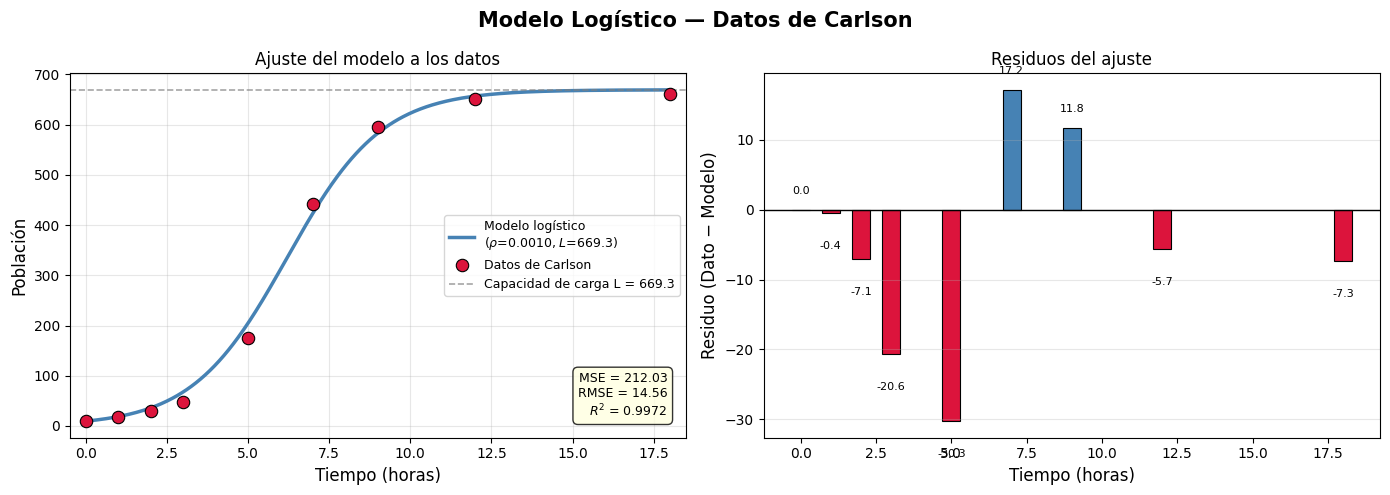

Gráfica guardada como modelo_logistico_carlson.png


In [8]:
# Generar curva suave del modelo
t_fine = np.linspace(0, 18, 500)
X_fine = logistic_model(t_fine, rho_opt, L_opt)

# ---- Figura principal ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Modelo Logístico — Datos de Carlson', fontsize=15, fontweight='bold')

# --- Panel izquierdo: ajuste del modelo ---
ax1 = axes[0]
ax1.plot(t_fine, X_fine, '-', color='steelblue', linewidth=2.5,
         label=f'Modelo logístico\n($\\rho$={rho_opt:.4f}, $L$={L_opt:.1f})')
ax1.scatter(horas, poblacion, color='crimson', s=80, zorder=5,
            label='Datos de Carlson', edgecolors='black', linewidths=0.8)

# Línea de capacidad de carga
ax1.axhline(y=L_opt, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Capacidad de carga L = {L_opt:.1f}')

ax1.set_xlabel('Tiempo (horas)', fontsize=12)
ax1.set_ylabel('Población', fontsize=12)
ax1.set_title('Ajuste del modelo a los datos', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 18.5)

# Anotación de métricas
ax1.text(0.97, 0.05,
         f'MSE = {mse:.2f}\nRMSE = {rmse:.2f}\n$R^2$ = {r2:.4f}',
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

# --- Panel derecho: residuos ---
ax2 = axes[1]
residuos = poblacion - y_pred
ax2.bar(horas, residuos, color=['crimson' if r < 0 else 'steelblue' for r in residuos],
        width=0.6, edgecolor='black', linewidth=0.8)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_xlabel('Tiempo (horas)', fontsize=12)
ax2.set_ylabel('Residuo (Dato − Modelo)', fontsize=12)
ax2.set_title('Residuos del ajuste', fontsize=12)
ax2.grid(True, axis='y', alpha=0.3)

# Etiquetas en barras
for h, r in zip(horas, residuos):
    ax2.text(h, r + (2 if r >= 0 else -4), f'{r:.1f}',
             ha='center', va='bottom' if r >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.savefig('modelo_logistico_carlson.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada como modelo_logistico_carlson.png')

## Iteración discreta del modelo

Verificamos el modelo discreto $X_{t+1} = X_t + \rho X_t (L - X_t)$ iterando desde $X_0$.

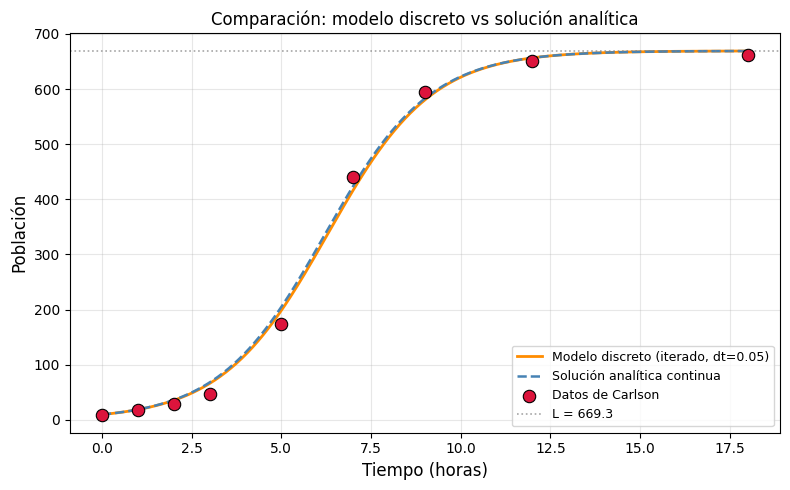


Parámetros finales: ρ = 0.001019, L = 669.3319
MSE = 212.0342


In [9]:
# Iterar el mapa logístico discreto
def iterar_modelo_discreto(X0, rho, L, t_max, dt=0.1):
    """Itera el modelo discreto con paso dt."""
    n_steps = int(t_max / dt) + 1
    t_arr = np.linspace(0, t_max, n_steps)
    X_arr = np.zeros(n_steps)
    X_arr[0] = X0
    for i in range(1, n_steps):
        X = X_arr[i-1]
        X_arr[i] = X + rho * X * (L - X) * dt
    return t_arr, X_arr

t_disc, X_disc = iterar_modelo_discreto(poblacion[0], rho_opt, L_opt, t_max=18, dt=0.05)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_disc, X_disc, '-', color='darkorange', linewidth=2,
        label='Modelo discreto (iterado, dt=0.05)')
ax.plot(t_fine, X_fine, '--', color='steelblue', linewidth=1.8,
        label='Solución analítica continua')
ax.scatter(horas, poblacion, color='crimson', s=80, zorder=5,
           label='Datos de Carlson', edgecolors='black', linewidths=0.8)
ax.axhline(y=L_opt, color='gray', linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'L = {L_opt:.1f}')
ax.set_xlabel('Tiempo (horas)', fontsize=12)
ax.set_ylabel('Población', fontsize=12)
ax.set_title('Comparación: modelo discreto vs solución analítica', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nParámetros finales: ρ = {rho_opt:.6f}, L = {L_opt:.4f}')
print(f'MSE = {mse:.4f}')